
## Analyse des Diamanten-Datensatzes

### Notwendige Bibliotheken importieren

In [260]:
import pandas as pd
import matplotlib.pyplot as plt

### Einlesen des Datensatzes

In [261]:
diamonds_dataframe = pd.read_csv('diamonds.csv')

### Exploration

In [262]:
diamonds_dataframe.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,x0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [263]:
diamonds_dataframe.shape

(53940, 11)

Entfernen der überflüssigen Spalte

In [264]:
diamonds_dataframe.drop('Unnamed: 0', axis=1, inplace=True)
#dropped_dataframe = diamonds_dataframe.drop('Unnamed: 0', axis=1)

diamonds_dataframe.head()
#dropped_dataframe.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,x0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Info des Dataframes

In [265]:
diamonds_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  object 
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(5), int64(1), object(4)
memory usage: 4.1+ MB


### Detailbeschreibung
* Numerische Werte

In [266]:
diamonds_dataframe.describe()

,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


* Sind die object-Spalten kategorische Variablen?
  * Kategorien enthalten halt nur eine eher beschränkte Menge von unterschiedlichen Werten

In [267]:
object_columns = diamonds_dataframe.dtypes[diamonds_dataframe.dtypes == 'object'].index
diamonds_dataframe[object_columns].describe()

,carat,cut,color,clarity
count,53940,53940,53940,53940
unique,274,5,7,8
top,0.3,Ideal,G,SI1
freq,2604,21551,11292,13065


* Ergebnis
  * Die object-Spalten (cut, color, clarity) dieses Datensatzes sind allesamt kategorisch
    * Damit kann sinnvoll nach diesen Spalten gruppiert werden

## Cleanup

### Warum ist carat nicht numerisch?

In [268]:
non_numeric_rows = pd.to_numeric(diamonds_dataframe['carat'], errors='coerce').isna()
diamonds_dataframe[non_numeric_rows]


,carat,cut,color,clarity,depth,table,price,x,y,z
4,x0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [269]:
diamonds_dataframe.loc[4, 'carat'] = 0.31#
diamonds_dataframe['carat'] = pd.to_numeric(diamonds_dataframe['carat'])
diamonds_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


### Einführen von kategorisierten Spalten

In [270]:
object_columns = diamonds_dataframe.dtypes[diamonds_dataframe.dtypes == 'object'].index
for column in object_columns:
    diamonds_dataframe[column] = pd.Categorical(diamonds_dataframe[column])
diamonds_dataframe.info()    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [271]:
diamonds_dataframe.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Analyse

### Elementare Statistik-Informationen

In [272]:
diamonds_dataframe.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### Histogramm auf Basis des Gewichts

array([[<Axes: title={'center': 'carat'}>]], dtype=object)

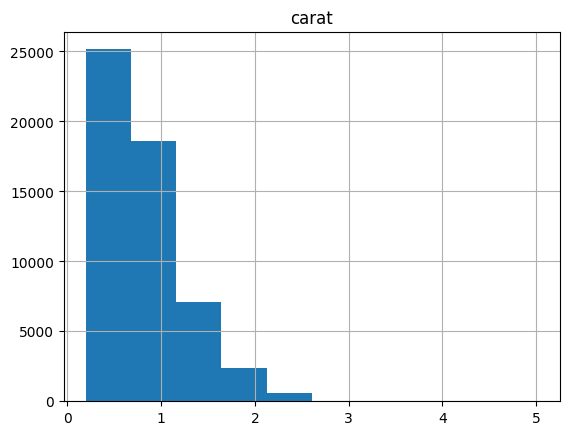

In [273]:
diamonds_dataframe.hist(column='carat')

* Welche Diamanten sind schwerer als 3.5?

In [296]:
CARAT_LIMIT = 3.5

In [297]:
diamonds_dataframe[diamonds_dataframe['carat'] > CARAT_LIMIT].count()

carat      9
cut        9
color      9
clarity    9
depth      9
table      9
price      9
x          9
y          9
z          9
dtype: int64

In [298]:
diamonds_dataframe[diamonds_dataframe['carat'] > CARAT_LIMIT]

,carat,cut,color,clarity,depth,table,price,x,y,z
23644,3.65,Fair,H,I1,67.1,53.0,11668,9.53,9.48,6.38
25998,4.01,Premium,I,I1,61.0,61.0,15223,10.14,10.10,6.17
25999,4.01,Premium,J,I1,62.5,62.0,15223,10.02,9.94,6.24
26444,4.00,Very Good,I,I1,63.3,58.0,15984,10.01,9.94,6.31
26534,3.67,Premium,I,I1,62.4,56.0,16193,9.86,9.81,6.13
27130,4.13,Fair,H,I1,64.8,61.0,17329,10.00,9.85,6.43
27415,5.01,Fair,J,I1,65.5,59.0,18018,10.74,10.54,6.98
27630,4.50,Fair,J,I1,65.8,58.0,18531,10.23,10.16,6.72
27679,3.51,Premium,J,VS2,62.5,59.0,18701,9.66,9.63,6.03


array([[<Axes: title={'center': 'carat'}>]], dtype=object)

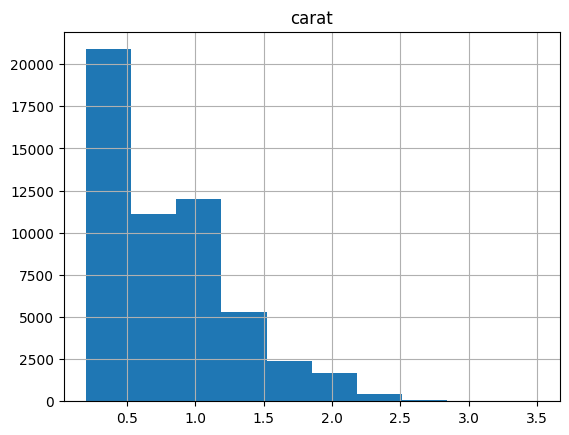

In [306]:
diamonds_dataframe[diamonds_dataframe['carat'] <= CARAT_LIMIT].hist(column='carat')

### Histogramm mit 20 Bins, das die Diamanten mit einem Gewicht > 3.5 darstellt

array([[<Axes: title={'center': 'carat'}>]], dtype=object)

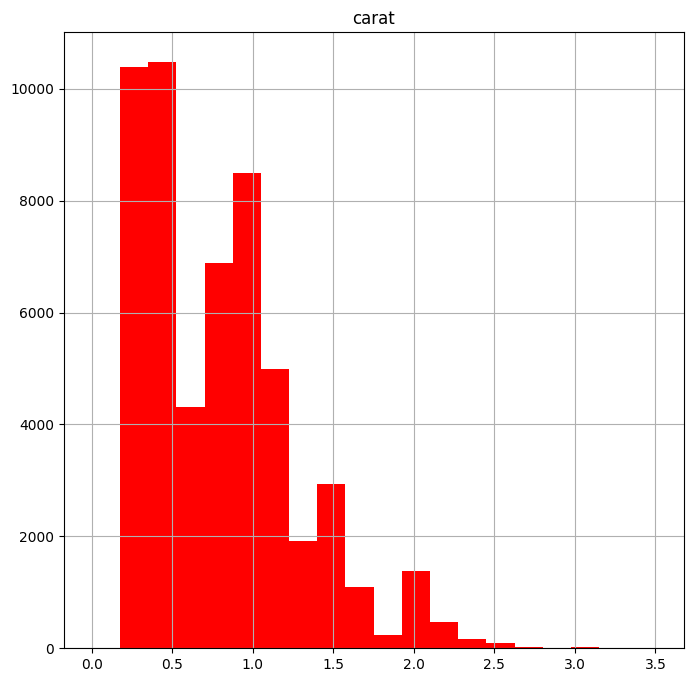

In [299]:
diamonds_dataframe.hist(column="carat",
              figsize=(8,8),         
              color="red",          
              bins=20,               
              range= (0,3.5))

array([[<Axes: title={'center': 'carat'}>]], dtype=object)

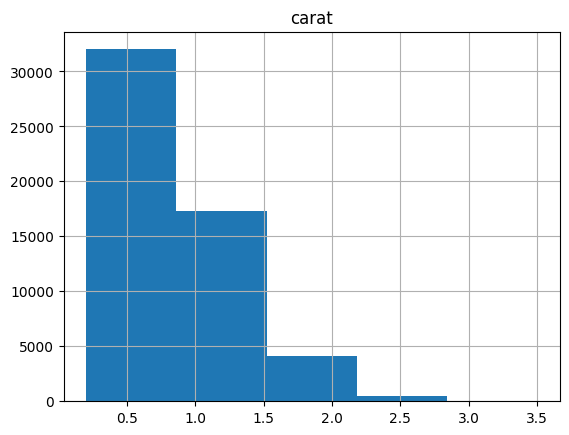

In [307]:
diamonds_dataframe[diamonds_dataframe['carat'] <= CARAT_LIMIT].hist(column='carat', bins=5)

array([[<Axes: title={'center': 'price'}>]], dtype=object)

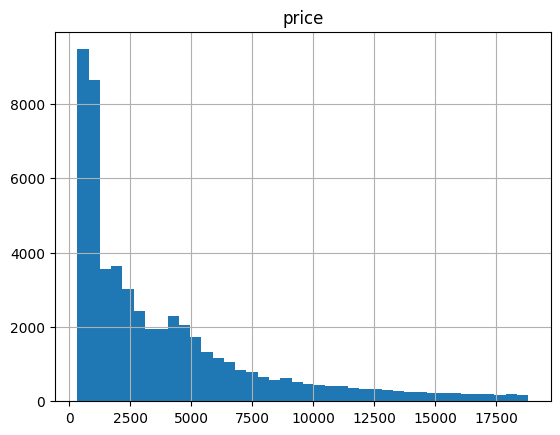

In [309]:
#diamonds_dataframe.hist(column='clarity') # no histogram for non-numerics
diamonds_dataframe.hist(column='price', bins=40)

C:\Users\raine\AppData\Local\Temp\ipykernel_13308\530462521.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diamonds_dataframe.hist(column='price', by='cut')


array([[<Axes: title={'center': 'Fair'}>,
        <Axes: title={'center': 'Good'}>],
       [<Axes: title={'center': 'Ideal'}>,
        <Axes: title={'center': 'Premium'}>],
       [<Axes: title={'center': 'Very Good'}>, <Axes: >]], dtype=object)

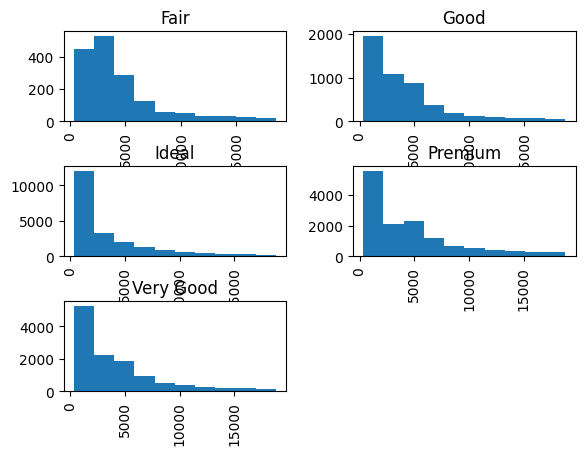

In [314]:
diamonds_dataframe.hist(column='price', by='cut')

### Boxplots

<Axes: >

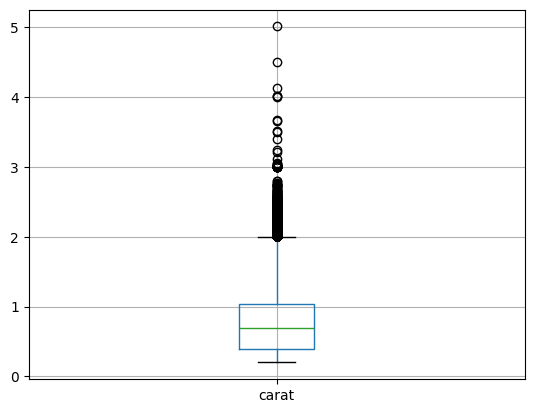

In [303]:
diamonds_dataframe.boxplot(column="carat")

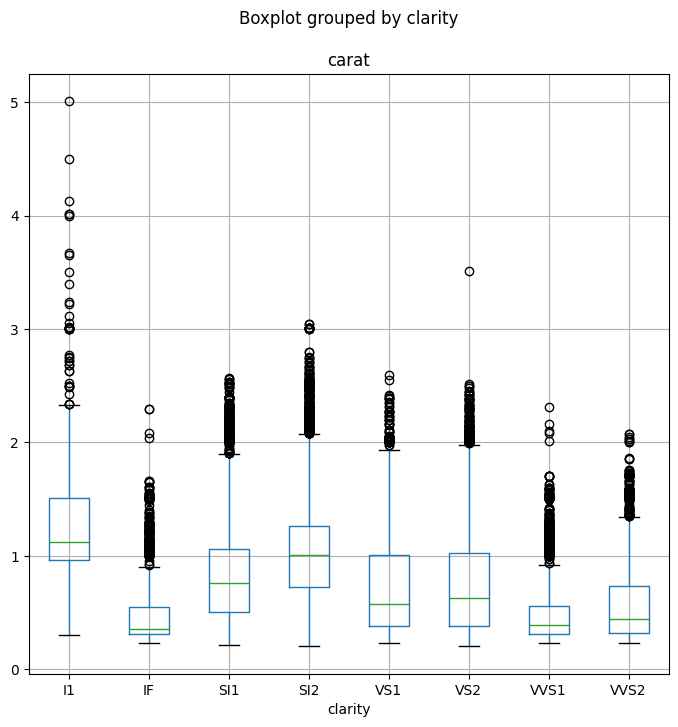

In [304]:
diamonds_dataframe.boxplot(column="carat",        # Column to plot
                 by= "clarity",         # Column to split upon
                 figsize= (8,8));       # Figure size

### Seaborn Heatmap

<Axes: >

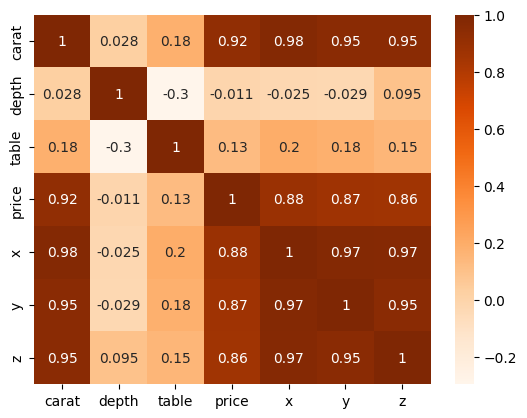

In [324]:
import seaborn as sns
import numpy as np

sns.heatmap(diamonds_dataframe.select_dtypes(include=np.number).corr(), annot=True, cmap='Oranges')